# TimesFM 2.5: Time Series Forecasting with Transformers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/timesfm2_5.ipynb)

[TimesFM 2.5](https://huggingface.co/google/timesfm-2.5-200m-transformers) is a pretrained time-series foundation model from Google Research. It provides accurate zero-shot forecasts across different domains, forecasting horizons, and temporal granularities.

This notebook demonstrates:
1. **Zero-shot forecasting** on synthetic and real-world time series
2. **Quantile (probabilistic) predictions** with uncertainty estimation
3. **Attention backend comparison** (eager, SDPA, Flash Attention 2)
4. **Fine-tuning with PEFT (LoRA)** on a custom dataset

Key advantages of using TimesFM 2.5 via Transformers:
- Native support for all attention backends (SDPA, Flash Attention 2, Flex Attention) through the standard `attn_implementation` API
- Standard `from_pretrained` / `save_pretrained` workflow
- Easy fine-tuning with PEFT adapters (LoRA, QLoRA, etc.)
- Compatible with the broader Transformers ecosystem

## Setup

Install the required packages. We need the latest `transformers` from main for TimesFM 2.5 support.

In [ ]:
%pip install -q git+https://github.com/huggingface/transformers.git accelerate peft matplotlib pandas

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from transformers import TimesFm2_5ModelForPrediction

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. Zero-Shot Forecasting

TimesFM 2.5 can forecast time series out-of-the-box without any training. Let's load the pretrained model and run inference on some synthetic signals.

In [2]:
model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    revision="refs/pr/3",
    device_map=device,
)
model.eval()
print(f"Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Horizon length: {model.config.horizon_length}")
print(f"Context length: {model.config.context_length}")
print(f"Quantiles: {model.config.quantiles}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Model loaded with 231,289,280 parameters
Horizon length: 128
Context length: 16384
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


### Forecasting synthetic signals

The model accepts a list of 1D tensors as input (variable-length time series) and returns:
- `mean_predictions`: point forecasts of shape `(batch_size, horizon_length)`
- `full_predictions`: quantile forecasts of shape `(batch_size, horizon_length, num_quantiles)`

In [3]:
# Create synthetic time series of different lengths
t1 = np.linspace(0, 20, 200)
t2 = np.linspace(0, 10, 300)
t3 = np.linspace(0, 15, 400)

signals = {
    "Sine wave": np.sin(t1),
    "Trend + seasonality": 0.05 * t2 + np.sin(2 * np.pi * t2 / 50),
    "Damped oscillation": np.exp(-0.01 * t3) * np.sin(t3),
}

past_values = [
    torch.tensor(s, dtype=torch.float32, device=device) for s in signals.values()
]

with torch.no_grad():
    outputs = model(past_values=past_values)

print(f"Mean predictions shape: {outputs.mean_predictions.shape}")
print(f"Full predictions shape: {outputs.full_predictions.shape}")

Mean predictions shape: torch.Size([3, 128])
Full predictions shape: torch.Size([3, 128, 10])


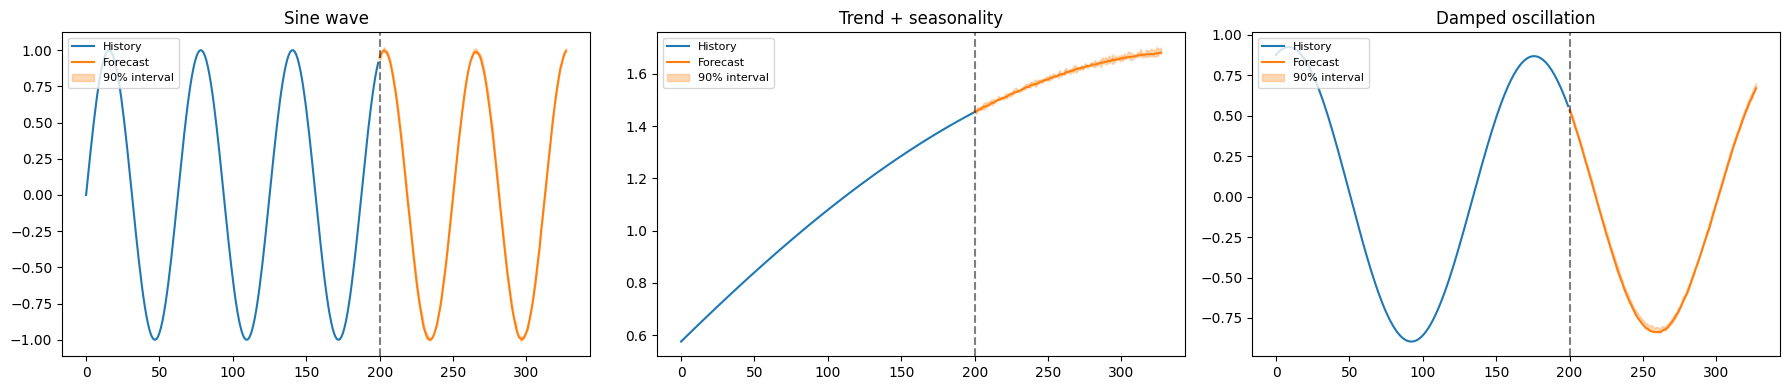

In [4]:
def plot_forecasts(signals, outputs, horizon_length, quantile_idx_low=0, quantile_idx_high=-1, history_length=200):
    """Plot historical data with forecasts and prediction intervals."""
    fig, axes = plt.subplots(1, len(signals), figsize=(6 * len(signals), 4))
    if len(signals) == 1:
        axes = [axes]

    mean_preds = outputs.mean_predictions.cpu().numpy()
    full_preds = outputs.full_predictions.cpu().numpy()

    for idx, (name, signal) in enumerate(signals.items()):
        ax = axes[idx]
        context = signal[-history_length:]
        forecast = mean_preds[idx, :horizon_length]
        q_low = full_preds[idx, :horizon_length, quantile_idx_low]
        q_high = full_preds[idx, :horizon_length, quantile_idx_high]

        t_hist = np.arange(len(context))
        t_pred = np.arange(len(context), len(context) + horizon_length)

        ax.plot(t_hist, context, label="History", color="tab:blue")
        ax.plot(t_pred, forecast, label="Forecast", color="tab:orange")
        ax.fill_between(t_pred, q_low, q_high, alpha=0.3, color="tab:orange", label="90% interval")
        ax.axvline(x=len(context), color="black", linestyle="--", alpha=0.5)
        ax.set_title(name)
        ax.legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


plot_forecasts(signals, outputs, model.config.horizon_length)

### Forecasting real-world data

Let's try the model on the Electricity Transformer Temperature (ETTh1) dataset, a commonly used benchmark for time series forecasting.

In [5]:
# Load ETTh1 dataset
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url, parse_dates=["date"])
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


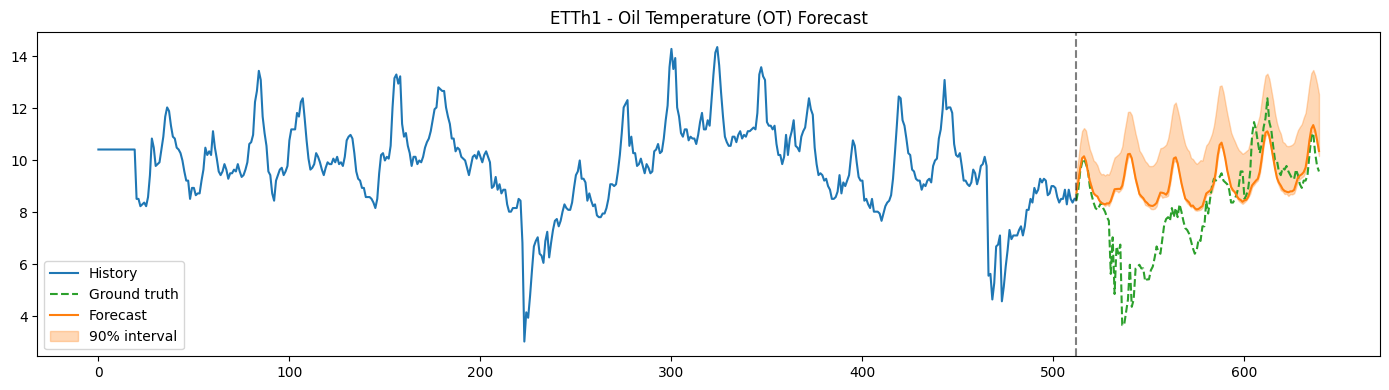

MAE: 1.3000


In [6]:
# Forecast the "OT" (Oil Temperature) column
target_col = "OT"
context_len = 512
horizon = model.config.horizon_length

# Use last context_len + horizon points: context for input, horizon for ground truth
ts = df[target_col].values
context = ts[-(context_len + horizon):-horizon]
ground_truth = ts[-horizon:]

past_values = [torch.tensor(context, dtype=torch.float32, device=device)]

with torch.no_grad():
    outputs = model(past_values=past_values)

forecast = outputs.mean_predictions[0].cpu().numpy()
full_preds = outputs.full_predictions[0].cpu().numpy()

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
t_hist = np.arange(context_len)
t_pred = np.arange(context_len, context_len + horizon)

ax.plot(t_hist, context, label="History", color="tab:blue")
ax.plot(t_pred, ground_truth, label="Ground truth", color="tab:green", linestyle="--")
ax.plot(t_pred, forecast, label="Forecast", color="tab:orange")
ax.fill_between(t_pred, full_preds[:, 0], full_preds[:, -1], alpha=0.3, color="tab:orange", label="90% interval")
ax.axvline(x=context_len, color="black", linestyle="--", alpha=0.5)
ax.set_title(f"ETTh1 - Oil Temperature ({target_col}) Forecast")
ax.legend()
plt.tight_layout()
plt.show()

# Compute MAE
mae = np.abs(forecast - ground_truth).mean()
print(f"MAE: {mae:.4f}")

### Batch forecasting multiple columns

TimesFM 2.5 accepts a list of variable-length time series, making it easy to forecast multiple series at once.

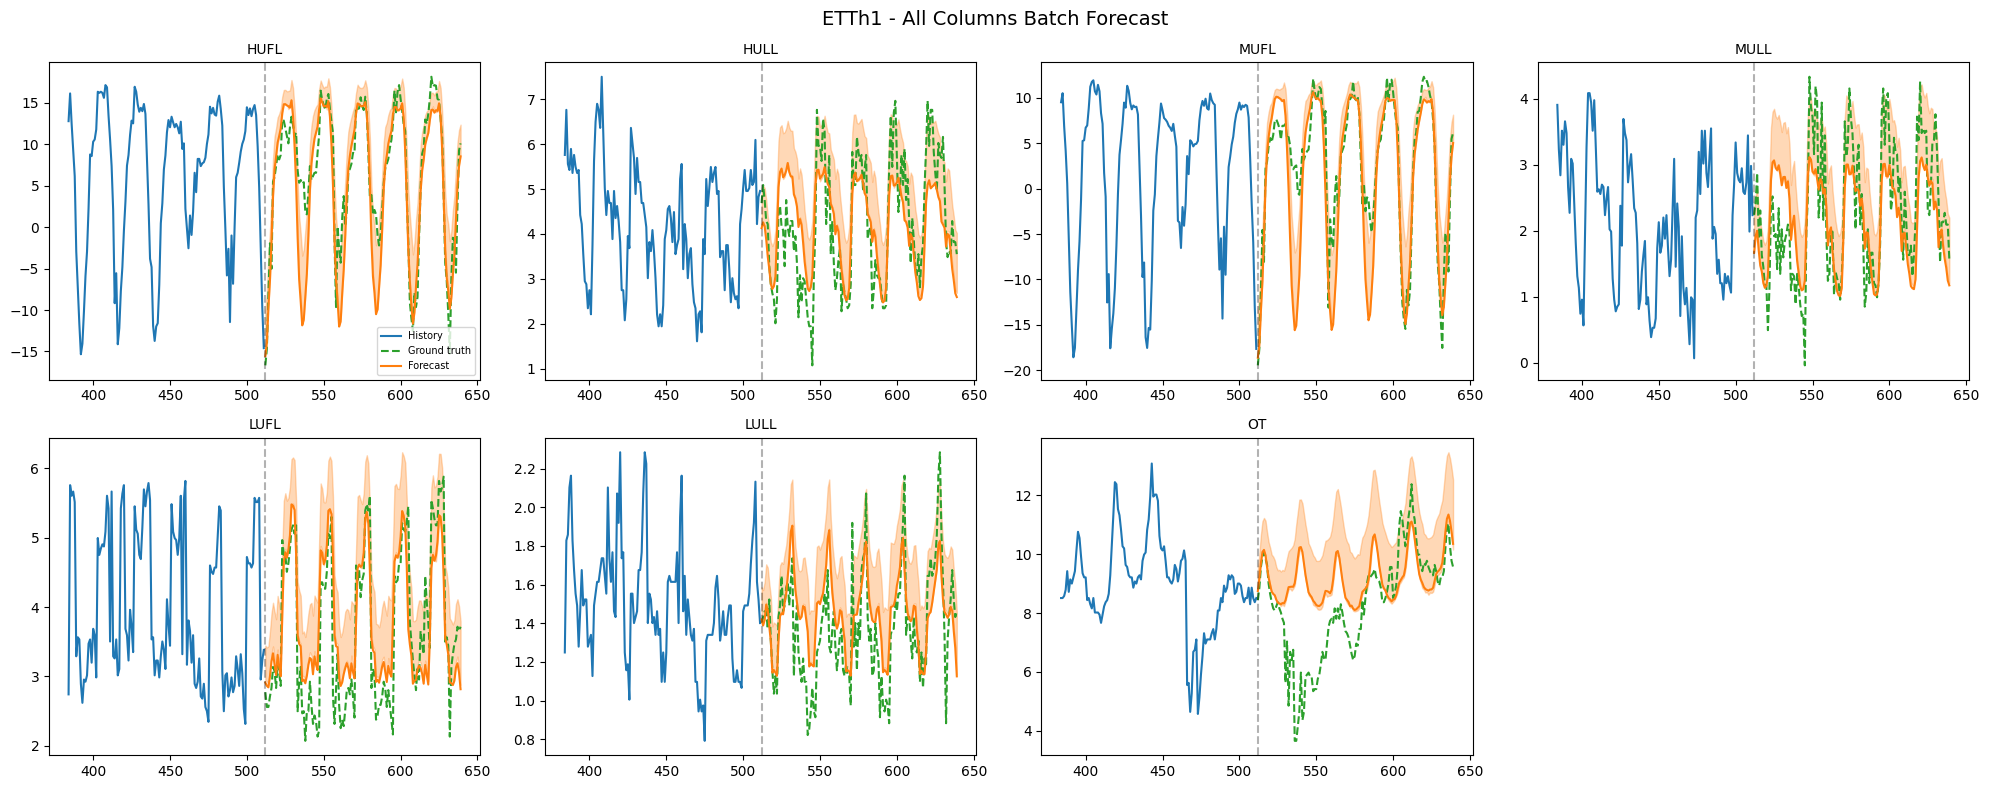

In [7]:
# Forecast all 7 columns of ETTh1 in a single batch
ts_cols = [c for c in df.columns if c != "date"]

past_values = []
ground_truths = []
for col in ts_cols:
    ts = df[col].values
    past_values.append(torch.tensor(ts[-(context_len + horizon):-horizon], dtype=torch.float32, device=device))
    ground_truths.append(ts[-horizon:])

with torch.no_grad():
    outputs = model(past_values=past_values)

# Plot all forecasts
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, col in enumerate(ts_cols):
    ax = axes[idx]
    forecast = outputs.mean_predictions[idx].cpu().numpy()
    full_preds = outputs.full_predictions[idx].cpu().numpy()
    gt = ground_truths[idx]

    t_hist = np.arange(context_len)
    t_pred = np.arange(context_len, context_len + horizon)

    ax.plot(t_hist[-128:], past_values[idx].cpu().numpy()[-128:], label="History", color="tab:blue")
    ax.plot(t_pred, gt, label="Ground truth", color="tab:green", linestyle="--")
    ax.plot(t_pred, forecast, label="Forecast", color="tab:orange")
    ax.fill_between(t_pred, full_preds[:, 0], full_preds[:, -1], alpha=0.3, color="tab:orange")
    ax.axvline(x=context_len, color="black", linestyle="--", alpha=0.3)
    ax.set_title(col, fontsize=10)
    if idx == 0:
        ax.legend(fontsize=7)

# Hide the last empty subplot
axes[-1].set_visible(False)
plt.suptitle("ETTh1 - All Columns Batch Forecast", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Attention Backend Comparison

One of the key benefits of using TimesFM 2.5 via Transformers is native support for different attention implementations:
- **Eager**: Standard PyTorch attention (baseline)
- **SDPA**: PyTorch's `scaled_dot_product_attention` (fused kernels)
- **Flash Attention 2**: Memory-efficient attention (requires `flash-attn` package and a compatible GPU)

All backends produce equivalent outputs but differ in speed and memory usage.

In [8]:
import time

# Prepare a batch of longer sequences for benchmarking
benchmark_input = [
    torch.tensor(np.sin(np.linspace(0, 20, 2048)), dtype=torch.float32, device=device)
    for _ in range(8)
]

backends = ["eager", "sdpa"]

# Check if flash_attn is available (requires compatible GPU)
try:
    from transformers.utils import is_flash_attn_2_available
    if is_flash_attn_2_available():
        backends.append("flash_attention_2")
        print("Flash Attention 2 is available!")
    else:
        print("Flash Attention 2 is not available, benchmarking eager and SDPA only.")
except ImportError:
    print("Flash Attention 2 is not available, benchmarking eager and SDPA only.")

results = {}

for backend in backends:
    print(f"\nLoading model with attn_implementation='{backend}'...")
    m = TimesFm2_5ModelForPrediction.from_pretrained(
        "google/timesfm-2.5-200m-transformers",
        revision="refs/pr/3",
        attn_implementation=backend,
        torch_dtype=torch.bfloat16 if backend == "flash_attention_2" else torch.float32,
        device_map=device,
    )
    m.eval()

    # Warmup
    with torch.no_grad():
        _ = m(past_values=benchmark_input[:1])

    # Benchmark
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    n_runs = 5
    with torch.no_grad():
        for _ in range(n_runs):
            out = m(past_values=benchmark_input)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - start) / n_runs

    results[backend] = {
        "time_ms": elapsed * 1000,
        "predictions": out.mean_predictions.float().cpu(),
    }
    print(f"  {backend}: {elapsed*1000:.1f} ms/batch")
    del m
    if device == "cuda":
        torch.cuda.empty_cache()

Flash Attention 2 is not available, benchmarking eager and SDPA only.

Loading model with attn_implementation='eager'...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

  eager: 4965.4 ms/batch

Loading model with attn_implementation='sdpa'...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

  sdpa: 3712.2 ms/batch


Max diff (eager vs sdpa): 5.96e-07


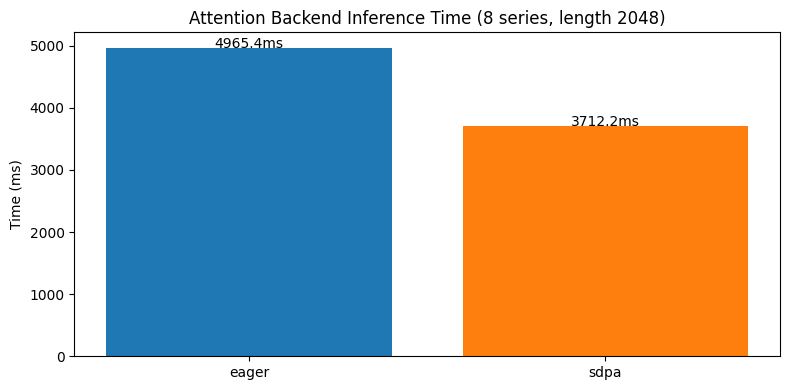

In [9]:
# Verify numerical equivalence between backends
reference = results["eager"]["predictions"]
for backend, data in results.items():
    if backend == "eager":
        continue
    diff = (reference - data["predictions"]).abs().max().item()
    print(f"Max diff (eager vs {backend}): {diff:.2e}")

# Plot timing comparison
fig, ax = plt.subplots(figsize=(8, 4))
backend_names = list(results.keys())
times = [results[b]["time_ms"] for b in backend_names]
bars = ax.bar(backend_names, times, color=["tab:blue", "tab:orange", "tab:green"][:len(backend_names)])
ax.set_ylabel("Time (ms)")
ax.set_title("Attention Backend Inference Time (8 series, length 2048)")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f"{t:.1f}ms", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Fine-Tuning with PEFT (LoRA)

TimesFM 2.5 can be fine-tuned on custom datasets using parameter-efficient methods like LoRA. This is especially useful when you have domain-specific data and want to adapt the model without updating all 200M parameters.

We'll fine-tune on the ETTh1 dataset using a sliding window approach.

In [8]:
from torch.utils.data import Dataset, DataLoader
from peft import LoraConfig, get_peft_model, TaskType


class TimeSeriesSlidingWindowDataset(Dataset):
    """Sliding window dataset for time series fine-tuning."""

    def __init__(self, data, context_len, horizon_len, stride=1):
        self.data = data
        self.context_len = context_len
        self.horizon_len = horizon_len
        self.stride = stride
        self.n_windows = (len(data) - context_len - horizon_len) // stride + 1

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        start = idx * self.stride
        context = self.data[start : start + self.context_len]
        target = self.data[start + self.context_len : start + self.context_len + self.horizon_len]
        return torch.tensor(context, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

In [9]:
# Prepare ETTh1 data for fine-tuning
target_col = "OT"
ts = df[target_col].values.astype(np.float32)

# Normalize
ts_mean, ts_std = ts.mean(), ts.std()
ts_norm = (ts - ts_mean) / ts_std

# Train/val/test split (standard ETT boundaries)
train_end = 8640
val_end = 11520

context_len = 512
horizon_len = 96  # Shorter horizon for fine-tuning

train_dataset = TimeSeriesSlidingWindowDataset(ts_norm[:train_end], context_len, horizon_len, stride=horizon_len)
val_dataset = TimeSeriesSlidingWindowDataset(ts_norm[train_end:val_end], context_len, horizon_len, stride=horizon_len)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train windows: {len(train_dataset)}, Val windows: {len(val_dataset)}")

Train windows: 84, Val windows: 24


In [14]:
# Load a fresh model for fine-tuning
ft_model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    revision="refs/pr/3",
    device_map=device,
)

# Apply LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules="all-linear",
    lora_dropout=0.05,
    bias="none",
)

ft_model = get_peft_model(ft_model, lora_config)
ft_model.print_trainable_parameters()

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

trainable params: 1,382,912 || all params: 232,672,192 || trainable%: 0.5944


In [ ]:
# Training loop
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
num_epochs = 10
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Train
    ft_model.train()
    epoch_train_loss = 0
    n_batches = 0
    for context, target in train_loader:
        context, target = context.to(device), target.to(device)

        outputs = ft_model(past_values=context, future_values=target)

        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_train_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validate
    ft_model.eval()
    epoch_val_loss = 0
    n_val_batches = 0
    with torch.no_grad():
        for context, target in val_loader:
            context, target = context.to(device), target.to(device)
            outputs = ft_model(past_values=context, future_values=target)
            epoch_val_loss += outputs.loss.item()
            n_val_batches += 1

    avg_val_loss = epoch_val_loss / n_val_batches
    val_losses.append(avg_val_loss)
    scheduler.step()

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Save LoRA adapter weights
        ft_model.save_pretrained("timesfm2_5-etth1-lora")

    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {avg_train_loss:.4f}, Val loss: {avg_val_loss:.4f}")

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

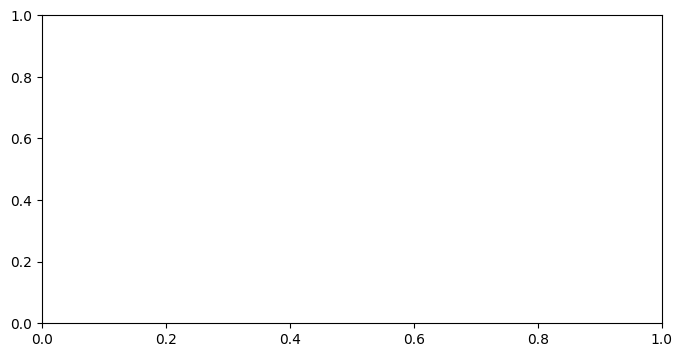

In [12]:
# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, num_epochs + 1), train_losses, label="Train loss", marker="o")
ax.plot(range(1, num_epochs + 1), val_losses, label="Val loss", marker="s")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Fine-tuning Loss Curves")
ax.legend()
plt.tight_layout()
plt.show()

### Compare zero-shot vs fine-tuned

Let's compare the zero-shot model with the LoRA fine-tuned model on the test set.

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

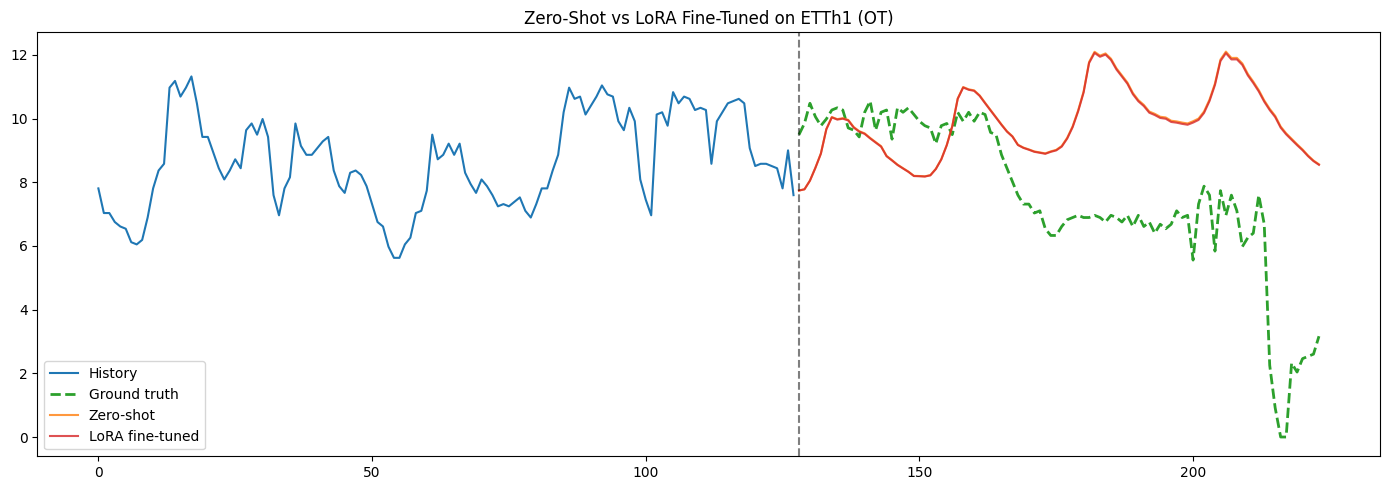

Zero-shot MAE: 2.9363
LoRA fine-tuned MAE: 2.9171
Improvement: 0.7%


In [13]:
# Evaluate on a test window
test_start = val_end
test_context = ts_norm[test_start : test_start + context_len]
test_target = ts_norm[test_start + context_len : test_start + context_len + horizon_len]

test_input = [torch.tensor(test_context, dtype=torch.float32, device=device)]
test_target_tensor = torch.tensor(test_target, dtype=torch.float32, device=device).unsqueeze(0)

# Zero-shot prediction (reload base model)
base_model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    revision="refs/pr/3",
    device_map=device,
)
base_model.eval()

with torch.no_grad():
    base_out = base_model(past_values=test_input)
    ft_out = ft_model(past_values=test_input)

# Denormalize for plotting
base_forecast = base_out.mean_predictions[0, :horizon_len].cpu().numpy() * ts_std + ts_mean
ft_forecast = ft_out.mean_predictions[0, :horizon_len].cpu().numpy() * ts_std + ts_mean
actual = test_target * ts_std + ts_mean
context_plot = test_context[-128:] * ts_std + ts_mean

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 5))
t_hist = np.arange(len(context_plot))
t_pred = np.arange(len(context_plot), len(context_plot) + horizon_len)

ax.plot(t_hist, context_plot, label="History", color="tab:blue")
ax.plot(t_pred, actual, label="Ground truth", color="tab:green", linestyle="--", linewidth=2)
ax.plot(t_pred, base_forecast, label="Zero-shot", color="tab:orange", alpha=0.8)
ax.plot(t_pred, ft_forecast, label="LoRA fine-tuned", color="tab:red", alpha=0.8)
ax.axvline(x=len(context_plot), color="black", linestyle="--", alpha=0.5)
ax.set_title("Zero-Shot vs LoRA Fine-Tuned on ETTh1 (OT)")
ax.legend()
plt.tight_layout()
plt.show()

base_mae = np.abs(base_forecast - actual).mean()
ft_mae = np.abs(ft_forecast - actual).mean()
print(f"Zero-shot MAE: {base_mae:.4f}")
print(f"LoRA fine-tuned MAE: {ft_mae:.4f}")
print(f"Improvement: {(base_mae - ft_mae) / base_mae * 100:.1f}%")

### Loading and reusing a saved LoRA adapter

The LoRA adapter weights can be saved and loaded separately from the base model, making them easy to share and version.

In [ ]:
from peft import PeftModel

# Load base model + LoRA adapter
base = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    revision="refs/pr/3",
    device_map=device,
)
loaded_model = PeftModel.from_pretrained(base, "timesfm2_5-etth1-lora")
loaded_model.eval()

with torch.no_grad():
    loaded_out = loaded_model(past_values=test_input)

# Verify outputs match
diff = (ft_out.mean_predictions - loaded_out.mean_predictions).abs().max().item()
print(f"Max diff between saved and loaded adapter: {diff:.2e}")

## Summary

In this notebook, we demonstrated the key capabilities of TimesFM 2.5 in Transformers:

- **Zero-shot forecasting**: The model provides accurate forecasts on unseen data without any training, including quantile uncertainty estimates.
- **Batch forecasting**: Multiple time series of different lengths can be forecast in a single call.
- **Attention backends**: Native support for eager, SDPA, and Flash Attention 2, with numerically equivalent outputs and different performance characteristics.
- **PEFT fine-tuning**: LoRA adapters can be applied to adapt the model to domain-specific data with minimal trainable parameters.

For more information, see:
- [Model card](https://huggingface.co/google/timesfm-2.5-200m-transformers)
- [Transformers documentation](https://huggingface.co/docs/transformers/model_doc/timesfm2_5)
- [Original paper](https://huggingface.co/papers/2310.10688)